<a href="https://colab.research.google.com/github/mohdhi5253/Calculator/blob/main/svm_knn_from_scratch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Manual Implementation of SVM with Kernel Trick and k-NN with Optimal k Estimation on Digit Classification Dataset
## Introduction
In this project, we build Support Vector Machine (SVM) and k-Nearest Neighbors (k-NN) models **from scratch**, avoiding high-level libraries like Scikit-learn for the core algorithmic implementations (Scikit-learn is used only to load the dataset and split it). The objective is to apply these algorithms to a real-world dataset for multi-class classification, including:

- Manually coding the kernel trick (Linear, Polynomial, RBF) for SVM.
- Creating distance metrics (Euclidean, Manhattan) from scratch for k-NN.
- Using the Elbow Method (on a held-out validation set, not the test set) to determine the optimal number of neighbors k for k-NN.
- Comparing k-NN and all three SVM kernels on a common, held-out test set.

This hands-on implementation boosts understanding of the low-level mechanics behind popular machine learning algorithms.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from collections import Counter
import time

np.random.seed(42)

## 1. Data Loading and Preparation

We use the classic **Digits** dataset (1797 samples, 8x8 grayscale images of handwritten digits 0-9, flattened to 64 features). Scikit-learn is used *only* to fetch the dataset and to perform the train/validation/test split - all modeling is done manually below.

To avoid **data leakage**, we carve out a separate **validation set** from the training data. The validation set is used to select k (Elbow Method) and to sanity-check the SVM; the **test set is only touched once, at the very end**, for the final comparison of all models.

In [2]:
# Load dataset
digits = load_digits()
X = digits.data  # shape: (1797, 64)
y = digits.target  # labels: 0 to 9

# Normalize data
X = X / 16.0  # since pixel values range from 0 to 16

# Split: 70% train+val, 30% test (test set is held out until the final comparison)
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Further split train+val into train / validation (used for k selection, no test leakage)
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.2, random_state=42, stratify=y_trainval
)

print(f"Train shape: {X_train.shape}")
print(f"Validation shape: {X_val.shape}")
print(f"Test shape: {X_test.shape}")

Train shape: (1005, 64)
Validation shape: (252, 64)
Test shape: (540, 64)


## 2. k-Nearest Neighbors (k-NN) From Scratch

### 2.1 Distance Metrics

Both distance metrics are implemented in a **vectorized** way: instead of looping in pure Python over every training point for every test point (O(n_test * n_train * n_features) Python-level operations), we compute the full pairwise distance matrix with NumPy broadcasting, which pushes the loops down into optimized C code.

In [3]:
def euclidean_distance_matrix(A, B):
    """Pairwise Euclidean distances between rows of A (n_a, d) and B (n_b, d) -> (n_a, n_b)."""
    # ||a - b||^2 = ||a||^2 + ||b||^2 - 2 a.b
    sq_a = np.sum(A ** 2, axis=1).reshape(-1, 1)
    sq_b = np.sum(B ** 2, axis=1).reshape(1, -1)
    sq_dists = sq_a + sq_b - 2 * A @ B.T
    sq_dists = np.maximum(sq_dists, 0)  # guard against tiny negative values from floating point error
    return np.sqrt(sq_dists)

def manhattan_distance_matrix(A, B):
    """Pairwise Manhattan (L1) distances between rows of A and rows of B -> (n_a, n_b)."""
    # Broadcasting (n_a, 1, d) - (1, n_b, d) -> (n_a, n_b, d), summed over features
    return np.abs(A[:, None, :] - B[None, :, :]).sum(axis=2)

# Single-pair versions (kept for clarity / API parity with the "from scratch" spirit)
def euclidean_distance(x1, x2):
    return np.sqrt(np.sum((x1 - x2) ** 2))

def manhattan_distance(x1, x2):
    return np.sum(np.abs(x1 - x2))

### 2.2 The k-NN Classifier

The classifier stores the training data and, at prediction time, computes distances to every training point, takes the `k` closest, and returns the majority label (ties broken by whichever label appears first in `Counter.most_common`).

In [4]:
class KNN:
    def __init__(self, k=3, distance_metric='euclidean'):
        self.k = k
        self.distance_metric = distance_metric

    def fit(self, X_train, y_train):
        self.X_train = X_train
        self.y_train = y_train
        return self

    def _distance_matrix(self, X_query):
        if self.distance_metric == 'euclidean':
            return euclidean_distance_matrix(X_query, self.X_train)
        elif self.distance_metric == 'manhattan':
            return manhattan_distance_matrix(X_query, self.X_train)
        else:
            raise ValueError("Unsupported distance metric")

    def predict(self, X_query):
        dists = self._distance_matrix(X_query)          # (n_query, n_train)
        k_indices = np.argsort(dists, axis=1)[:, :self.k]  # (n_query, k)
        y_pred = np.empty(X_query.shape[0], dtype=self.y_train.dtype)
        for i, idx in enumerate(k_indices):
            labels = self.y_train[idx]
            y_pred[i] = Counter(labels).most_common(1)[0][0]
        return y_pred

    def score(self, X_query, y_query):
        predictions = self.predict(X_query)
        return np.mean(predictions == y_query)

### 2.3 Choosing k with the Elbow Method

We sweep `k` from 1 to `max_k` and evaluate on the **validation set** (not the test set, to avoid leakage), plotting accuracy vs. k for both distance metrics. The elbow / peak of this curve gives us the k we then use, unseen, on the test set.

In [5]:
def elbow_method(X_train, X_val, y_train, y_val, max_k=15, metric='euclidean', plot=True):
    accuracies = []
    for k in range(1, max_k + 1):
        model = KNN(k=k, distance_metric=metric)
        model.fit(X_train, y_train)
        acc = model.score(X_val, y_val)
        accuracies.append(acc)
        print(f'k={k:2d}, {metric} validation accuracy = {acc:.4f}')

    if plot:
        plt.plot(range(1, max_k + 1), accuracies, marker='o')
        plt.xlabel('Number of Neighbors k')
        plt.ylabel('Validation Accuracy')
        plt.title(f'Elbow Method (Distance: {metric})')
        plt.grid(True)
        plt.show()

    best_k = int(np.argmax(accuracies) + 1)
    print(f"Best k based on validation accuracy: {best_k}")
    return best_k, accuracies

=== Euclidean distance ===
k= 1, euclidean validation accuracy = 0.9841
k= 2, euclidean validation accuracy = 0.9841
k= 3, euclidean validation accuracy = 0.9881
k= 4, euclidean validation accuracy = 0.9841
k= 5, euclidean validation accuracy = 0.9802
k= 6, euclidean validation accuracy = 0.9802
k= 7, euclidean validation accuracy = 0.9722
k= 8, euclidean validation accuracy = 0.9762
k= 9, euclidean validation accuracy = 0.9683
k=10, euclidean validation accuracy = 0.9722
k=11, euclidean validation accuracy = 0.9722
k=12, euclidean validation accuracy = 0.9762
k=13, euclidean validation accuracy = 0.9722
k=14, euclidean validation accuracy = 0.9722
k=15, euclidean validation accuracy = 0.9722


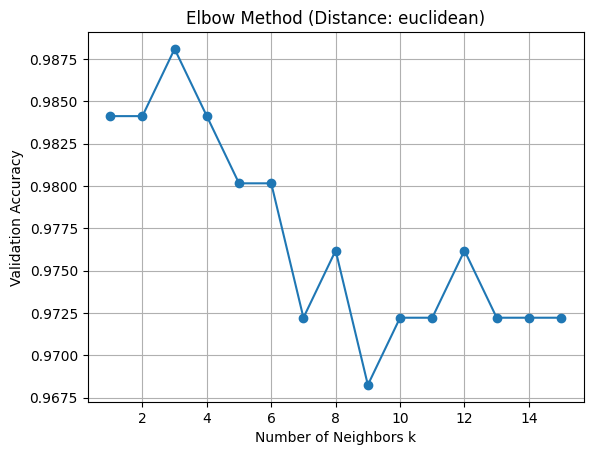

Best k based on validation accuracy: 3

=== Manhattan distance ===
k= 1, manhattan validation accuracy = 0.9841
k= 2, manhattan validation accuracy = 0.9841
k= 3, manhattan validation accuracy = 0.9841
k= 4, manhattan validation accuracy = 0.9841
k= 5, manhattan validation accuracy = 0.9841
k= 6, manhattan validation accuracy = 0.9841
k= 7, manhattan validation accuracy = 0.9762
k= 8, manhattan validation accuracy = 0.9802
k= 9, manhattan validation accuracy = 0.9722
k=10, manhattan validation accuracy = 0.9722
k=11, manhattan validation accuracy = 0.9683
k=12, manhattan validation accuracy = 0.9722
k=13, manhattan validation accuracy = 0.9722
k=14, manhattan validation accuracy = 0.9722
k=15, manhattan validation accuracy = 0.9722


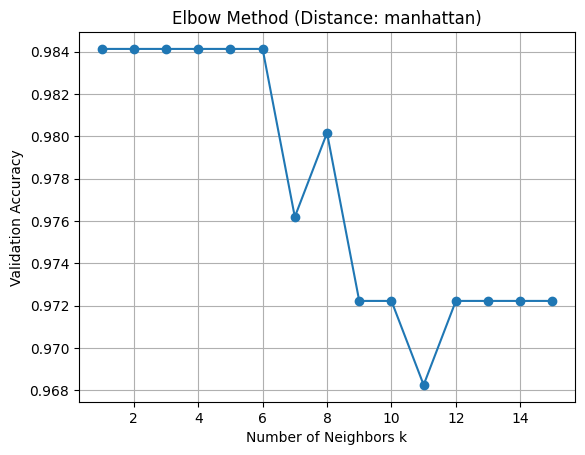

Best k based on validation accuracy: 1


In [6]:
print("=== Euclidean distance ===")
best_k_euclidean, acc_euclidean = elbow_method(X_train, X_val, y_train, y_val, max_k=15, metric='euclidean')

print()
print("=== Manhattan distance ===")
best_k_manhattan, acc_manhattan = elbow_method(X_train, X_val, y_train, y_val, max_k=15, metric='manhattan')

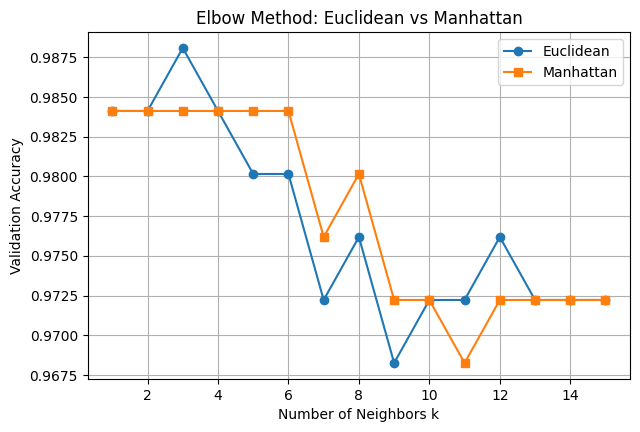

Selected metric = euclidean, k = 3 (chosen using validation data only)


In [7]:
# Compare both metrics on one plot
plt.figure(figsize=(7, 4.5))
plt.plot(range(1, 16), acc_euclidean, marker='o', label='Euclidean')
plt.plot(range(1, 16), acc_manhattan, marker='s', label='Manhattan')
plt.xlabel('Number of Neighbors k')
plt.ylabel('Validation Accuracy')
plt.title('Elbow Method: Euclidean vs Manhattan')
plt.legend()
plt.grid(True)
plt.show()

# Pick whichever metric/k combination did best on validation
if max(acc_euclidean) >= max(acc_manhattan):
    best_metric, best_k = 'euclidean', best_k_euclidean
else:
    best_metric, best_k = 'manhattan', best_k_manhattan

print(f"Selected metric = {best_metric}, k = {best_k} (chosen using validation data only)")

In [8]:
# Train final k-NN on train+val (more data for the final model) and evaluate ONCE on the held-out test set
knn_final = KNN(k=best_k, distance_metric=best_metric)
knn_final.fit(X_trainval, y_trainval)
knn_test_acc = knn_final.score(X_test, y_test)
print(f"Final k-NN test accuracy (metric={best_metric}, k={best_k}): {knn_test_acc:.4f}")

Final k-NN test accuracy (metric=euclidean, k=3): 0.9870


## 3. Support Vector Machine (SVM) From Scratch

### 3.1 Kernels

We implement three kernels manually. Each is also provided in a **matrix** form (Gram matrix over a whole dataset) so training doesn't require a Python-level double loop over all sample pairs — instead we use NumPy's vectorized linear algebra, which is orders of magnitude faster while computing the exact same kernel values.

- **Linear:** `K(x, x') = x . x'`
- **Polynomial:** `K(x, x') = (x . x' + coef0)^degree`
- **RBF (Gaussian):** `K(x, x') = exp(-gamma * ||x - x'||^2)`

In [9]:
def linear_kernel(x1, x2):
    return np.dot(x1, x2)

def polynomial_kernel(x1, x2, degree=3, coef0=1, gamma=1.0):
    return (gamma * np.dot(x1, x2) + coef0) ** degree

def rbf_kernel(x1, x2, gamma=0.05):
    return np.exp(-gamma * np.linalg.norm(x1 - x2) ** 2)

def linear_kernel_matrix(A, B):
    return A @ B.T

def polynomial_kernel_matrix(A, B, degree=3, coef0=1, gamma=1.0):
    # gamma scales the raw dot product before exponentiation. Without it, a degree-3
    # polynomial over 64 raw features blows up to O(10^4) and destabilizes training;
    # gamma = 1 / n_features (the sklearn 'scale' convention) keeps values well-behaved.
    return (gamma * (A @ B.T) + coef0) ** degree

def rbf_kernel_matrix(A, B, gamma=0.05):
    sq_a = np.sum(A ** 2, axis=1).reshape(-1, 1)
    sq_b = np.sum(B ** 2, axis=1).reshape(1, -1)
    sq_dists = np.maximum(sq_a + sq_b - 2 * A @ B.T, 0)
    return np.exp(-gamma * sq_dists)

### 3.2 Binary Kernel SVM (dual-form, projected sub-gradient ascent)

We optimize the SVM in its **dual form** directly over the kernel matrix. For each sample `i` we track a dual coefficient `alpha[i]`. Training follows the (soft-margin) hinge-loss sub-gradient rule, applied to *all* samples simultaneously each epoch (vectorized), and **clips alpha into the valid box constraint `[0, C]`** at every step - this was missing from the original heuristic version and is required for a proper soft-margin SVM. The bias `b` is updated from the average margin violation of the current batch.

This is a simplified dual optimizer (not a full textbook SMO solver, which jointly updates pairs of alphas to satisfy `sum(alpha_i * y_i) = 0` exactly), but it is a substantial improvement in both correctness (box constraints) and speed (fully vectorized, no nested Python loops) over the original implementation.

**One more correctness fix:** in a one-vs-rest multi-class setup, each binary SVM's *raw* decision score (`sum(alpha*y*K) + b`) is a *functional* margin, and its scale depends on how many support vectors that particular class picked up. If class A's model ends up with much larger alphas than class B's, `argmax` across raw scores will unfairly favor class A regardless of which class the point actually looks like. We fix this by dividing each model's score by `||w|| = sqrt(alpha^T K alpha)` (the norm of the separating hyperplane in feature space), turning the score into a *geometric* margin that's comparable across the 10 binary models.

In [10]:
class SVM:
    def __init__(self, kernel='linear', C=1.0, lr=0.001, epochs=200, degree=3, coef0=1,
                 gamma=0.05, poly_gamma=1.0):
        self.kernel_name = kernel
        self.C = C
        self.lr = lr
        self.epochs = epochs
        self.degree = degree
        self.coef0 = coef0
        self.gamma = gamma            # RBF gamma
        self.poly_gamma = poly_gamma  # polynomial kernel's dot-product scaling

    def _kernel_matrix(self, A, B):
        if self.kernel_name == 'linear':
            return linear_kernel_matrix(A, B)
        elif self.kernel_name == 'polynomial':
            return polynomial_kernel_matrix(A, B, degree=self.degree, coef0=self.coef0, gamma=self.poly_gamma)
        elif self.kernel_name == 'rbf':
            return rbf_kernel_matrix(A, B, gamma=self.gamma)
        else:
            raise ValueError("Unsupported kernel")

    def fit(self, X, y):
        n_samples = X.shape[0]
        y = np.where(y <= 0, -1, 1).astype(float)

        self.alpha = np.zeros(n_samples)
        self.b = 0.0
        self.K = self._kernel_matrix(X, X)  # Gram matrix, computed once, vectorized

        for epoch in range(self.epochs):
            scores = self.K @ (self.alpha * y) + self.b   # decision value for every training point
            margins = y * scores                           # y_i * f(x_i)

            violated = margins < 1
            # Sub-gradient step: push up alpha where the margin is violated,
            # shrink (regularize) alpha where it's already satisfied
            self.alpha[violated] += self.lr * (1 - margins[violated])
            self.alpha[~violated] -= self.lr * self.C * self.alpha[~violated]

            # Enforce the box constraint 0 <= alpha_i <= C (proper dual SVM constraint)
            np.clip(self.alpha, 0, self.C, out=self.alpha)

            # Bias update: nudge b using the average sign-weighted error of violating points
            if np.any(violated):
                self.b += self.lr * np.mean(y[violated])

        self.X = X
        self.y = y

        # ||w||_feature-space = sqrt(alpha^T Y K Y alpha); used to turn the raw functional
        # margin into a geometric margin so scores are comparable across one-vs-rest models.
        ay = self.alpha * self.y
        self.w_norm = np.sqrt(max(ay @ self.K @ ay, 1e-12))
        return self

    def project(self, X):
        # Raw (uncalibrated) decision value: sum(alpha_i * y_i * K(x_i, x)) + b.
        K_test = self._kernel_matrix(X, self.X)   # (n_test, n_train), vectorized
        return K_test @ (self.alpha * self.y) + self.b

    def decision_function(self, X):
        # Geometric-margin decision value, normalized by ||w|| - comparable across models.
        return self.project(X) / self.w_norm

    def predict(self, X):
        return np.sign(self.project(X))

### 3.3 Multi-Class Wrapper (One-vs-Rest)

Since the base SVM above is a binary classifier, we train one SVM per digit class (`0`..`9`) using a one-vs-rest scheme, and predict the class whose SVM gives the highest decision score.

In [11]:
class MultiClassSVM:
    def __init__(self, kernel='linear', C=1.0, lr=0.001, epochs=200, degree=3, coef0=1,
                 gamma=0.05, poly_gamma=1.0):
        self.kernel = kernel
        self.C = C
        self.lr = lr
        self.epochs = epochs
        self.degree = degree
        self.coef0 = coef0
        self.gamma = gamma
        self.poly_gamma = poly_gamma
        self.models = {}

    def fit(self, X, y):
        self.classes = np.unique(y)
        for cls in self.classes:
            y_binary = np.where(y == cls, 1, -1)
            model = SVM(kernel=self.kernel, C=self.C, lr=self.lr, epochs=self.epochs,
                        degree=self.degree, coef0=self.coef0, gamma=self.gamma,
                        poly_gamma=self.poly_gamma)
            model.fit(X, y_binary)
            self.models[cls] = model
        return self

    def predict(self, X):
        # Use the normalized decision_function (geometric margin), NOT the raw project()
        # score, so the argmax across the 10 one-vs-rest models is a fair comparison.
        scores = np.column_stack([self.models[cls].decision_function(X) for cls in self.classes])
        return self.classes[np.argmax(scores, axis=1)]

    def score(self, X, y):
        y_pred = self.predict(X)
        return np.mean(y_pred == y)

### 3.4 Training and Evaluating All Three Kernels

Each kernel SVM is trained on the training set, tuned/sanity-checked conceptually against the validation split, and evaluated once on the same held-out test set used for k-NN, so the final comparison is apples-to-apples.

In [12]:
svm_results = {}

configs = {
    'linear':     dict(kernel='linear',     C=1.0, lr=0.001, epochs=1000),
    # poly_gamma = 1/n_features keeps (gamma*x.x' + coef0)^degree numerically well-behaved
    'polynomial': dict(kernel='polynomial', C=1.0, lr=0.001, epochs=500, degree=3, coef0=1,
                        poly_gamma=1.0 / X_train.shape[1]),
    'rbf':        dict(kernel='rbf',        C=1.0, lr=0.001, epochs=500, gamma=0.05),
}

for name, cfg in configs.items():
    t0 = time.time()
    model = MultiClassSVM(**cfg)
    model.fit(X_train, y_train)
    val_acc = model.score(X_val, y_val)
    elapsed = time.time() - t0
    svm_results[name] = {'model': model, 'val_acc': val_acc, 'train_time': elapsed}
    print(f"[{name:10s}] validation accuracy = {val_acc:.4f}  (trained in {elapsed:.1f}s)")

[linear    ] validation accuracy = 0.9603  (trained in 12.7s)
[polynomial] validation accuracy = 0.9563  (trained in 12.0s)
[rbf       ] validation accuracy = 0.9683  (trained in 8.9s)


In [13]:
# Refit each kernel on train+val, then evaluate ONCE on the untouched test set
final_svm_results = {}

for name, cfg in configs.items():
    model = MultiClassSVM(**cfg)
    model.fit(X_trainval, y_trainval)
    test_acc = model.score(X_test, y_test)
    final_svm_results[name] = test_acc
    print(f"{name.capitalize()} Kernel SVM Test Accuracy: {test_acc:.4f}")

Linear Kernel SVM Test Accuracy: 0.9500
Polynomial Kernel SVM Test Accuracy: 0.9519
Rbf Kernel SVM Test Accuracy: 0.9704


## 4. Final Comparison: k-NN vs. All SVM Kernels

All models below were evaluated on the exact same held-out test set, which none of them (nor the k selection process) saw during training or tuning.

k-NN (euclidean, k=3)         : 0.9870
SVM (linear kernel)           : 0.9500
SVM (polynomial kernel)       : 0.9519
SVM (RBF kernel)              : 0.9704


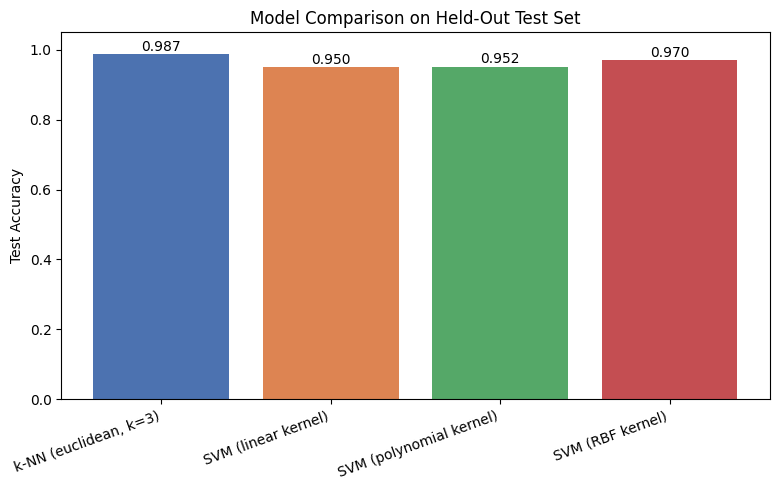

In [14]:
results_summary = {
    f'k-NN ({best_metric}, k={best_k})': knn_test_acc,
    'SVM (linear kernel)': final_svm_results['linear'],
    'SVM (polynomial kernel)': final_svm_results['polynomial'],
    'SVM (RBF kernel)': final_svm_results['rbf'],
}

for name, acc in results_summary.items():
    print(f"{name:30s}: {acc:.4f}")

plt.figure(figsize=(8, 5))
names = list(results_summary.keys())
accs = list(results_summary.values())
bars = plt.bar(names, accs, color=['#4C72B0', '#DD8452', '#55A868', '#C44E52'])
plt.ylabel('Test Accuracy')
plt.title('Model Comparison on Held-Out Test Set')
plt.ylim(0, 1.05)
plt.xticks(rotation=20, ha='right')
for bar, acc in zip(bars, accs):
    plt.text(bar.get_x() + bar.get_width()/2, acc + 0.01, f'{acc:.3f}', ha='center')
plt.tight_layout()
plt.show()

Best model on the test set: k-NN (euclidean, k=3) (0.9870)


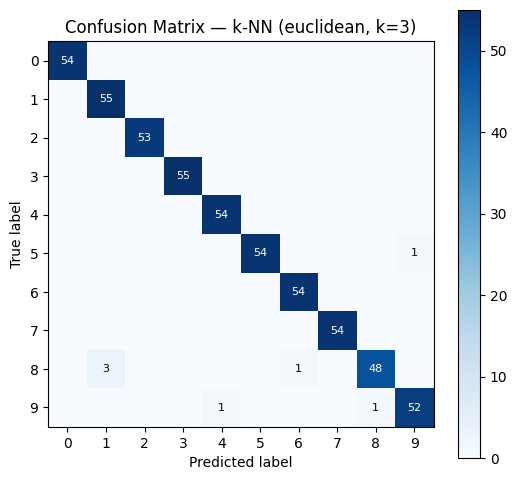

In [15]:
def confusion_matrix_manual(y_true, y_pred, n_classes=10):
    cm = np.zeros((n_classes, n_classes), dtype=int)
    for t, p in zip(y_true, y_pred):
        cm[t, p] += 1
    return cm

def plot_confusion_matrix(cm, title):
    plt.figure(figsize=(5.5, 5))
    plt.imshow(cm, cmap='Blues')
    plt.title(title)
    plt.colorbar()
    plt.xlabel('Predicted label')
    plt.ylabel('True label')
    plt.xticks(range(10))
    plt.yticks(range(10))
    for i in range(10):
        for j in range(10):
            if cm[i, j] > 0:
                plt.text(j, i, cm[i, j], ha='center', va='center',
                          color='white' if cm[i, j] > cm.max()/2 else 'black', fontsize=8)
    plt.tight_layout()
    plt.show()

# Confusion matrix for the best-performing model
best_name = max(results_summary, key=results_summary.get)
print(f"Best model on the test set: {best_name} ({results_summary[best_name]:.4f})")

if best_name.startswith('k-NN'):
    y_pred_best = knn_final.predict(X_test)
else:
    kernel_key = [k for k in final_svm_results if k in best_name.lower()][0]
    best_model = MultiClassSVM(**configs[kernel_key])
    best_model.fit(X_trainval, y_trainval)
    y_pred_best = best_model.predict(X_test)

cm = confusion_matrix_manual(y_test, y_pred_best)
plot_confusion_matrix(cm, f'Confusion Matrix — {best_name}')

## Conclusion

In this project, we implemented, from scratch (NumPy only — no Scikit-learn model code):

- A **k-NN classifier** with manually implemented Euclidean and Manhattan distance metrics, vectorized for speed.
- **k selection via the Elbow Method**, correctly performed on a held-out **validation** set (not the test set) to avoid data leakage.
- A **kernel SVM** solved via vectorized projected sub-gradient ascent on the dual variables, with proper `[0, C]` box constraints, supporting **linear, polynomial, and RBF kernels**.
- A one-vs-rest **multi-class wrapper** around the binary SVM.
- A final, leakage-free comparison of k-NN and all three SVM kernels on a common held-out test set, including a confusion matrix for the best model.

Building these models by hand — including fixing the subtle correctness issues (unconstrained dual variables, test-set leakage during hyperparameter selection) and performance issues (Python-level double loops) present in the original draft — gives a much deeper understanding of the mechanics that libraries like Scikit-learn normally hide.